# 안저 영상 혈관 분할 및 굴곡도 정량화 

**파이프라인:** FIVES로 U-Net 학습 → 분할 편향 점검 → 스켈레톤 기반 세그먼트별 굴곡도 → APTOS 2019(선택: EyePACS) 추론 → 굴곡도와 DR 등급의 관계 통계 분석

| 단계 | 내용 |
|---|---|
| 1 | 데이터 탐색, FOV 기준 크롭·크기 정규화, CLAHE |
| 2 | U-Net(ResNet34) + BCE·Dice·clDice 학습 |
| 3 | FIVES 테스트셋 분할 평가 (전체 및 질환군별) |
| 4 | 스켈레톤 → 세그먼트 분리 → 굴곡도 지표(DM, ICM, SOAM, CE, TD) |
| 5 | FIVES: 정답/예측 굴곡도 일치도(편향 점검), 질환군 간 비교 |
| 6 | APTOS 2019 추론 → 품질 필터 → DR 등급별 분석 + 민감도 분석 |
| 7 | (선택) EyePACS 확장: 환자당 한 눈 |

### 실행 전 Kaggle 설정
1. **Settings → Accelerator:** `GPU T4 x2` 또는 `GPU P100`
2. **Settings → Internet:** On (smp 설치와 ImageNet 가중치 다운로드에 필요, 휴대폰 인증 필요)
3. **Add Input**
   - FIVES 데이터셋 (검색어 `FIVES fundus vessel`) → 폴더 구조는 자동 탐색합니다. Input에 없으면 `CFG.FIVES_KAGGLEHUB`로 자동 다운로드를 시도합니다.
   - `APTOS 2019 Blindness Detection` 대회 데이터 (대회 규칙 동의 필요)
   - (선택) EyePACS 리사이즈 버전 (예: `diabetic-retinopathy-resized`) → 7절의 `CFG.EYEPACS_*` 경로 지정
4. 학습에 1시간 이상 걸리므로 **Save Version → Save & Run All**로 백그라운드 실행을 권장합니다.
   다음부터는 이 노트북의 출력(`unet_fives_best.pt`)을 Input으로 붙이고 `CFG.PRETRAINED_CKPT`에 경로를 넣으면 학습을 건너뜁니다.

> 모든 영상은 **FOV 지름 = `IMG_SIZE`(1024px)** 로 맞춘 뒤 처리합니다. 그래서 길이·곡률 단위(px)가 데이터셋 간에 비교 가능합니다.

In [1]:
# Kaggle 기본 이미지에는 torch, albumentations, statsmodels, scikit-image, opencv가 설치되어 있습니다.
!pip install -q segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 7.1 MB/s eta 0:00:00


In [25]:
import os, re, gc, math, random, time, warnings
from pathlib import Path
from collections import deque

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap
from scipy import ndimage as ndi
from scipy import stats
from scipy.interpolate import splprep, splev
from skimage.morphology import skeletonize
from joblib import Parallel, delayed
from tqdm.auto import tqdm

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
cv2.setNumThreads(0)


class CFG:
    # ---------- 경로 ----------
    INPUT = Path('/kaggle/input')
    WORK = Path('/kaggle/working')
    FIVES_ROOT = None                   # None이면 /kaggle/input에서 자동 탐색
    FIVES_KAGGLEHUB = 'nikitamanaenkov/fundus-image-dataset-for-vessel-segmentation'  # Input에 없으면 kagglehub로 다운로드 (None이면 사용 안 함)
    CFG.APTOS_ROOT = Path('/kaggle/input/competitions/aptos2019-blindness-detection')
    EYEPACS_CSV = None                  # 예: Path('/kaggle/input/diabetic-retinopathy-resized/trainLabels.csv')
    EYEPACS_IMG_DIR = None              # 예: Path('/kaggle/input/diabetic-retinopathy-resized/resized_train/resized_train')
    EYEPACS_EXT = '.jpeg'
    EYEPACS_MAX = 5000                  # 환자당 한 눈 선택 후 처리할 최대 영상 수 (None이면 전부)

    # ---------- 전처리 ----------
    IMG_SIZE = 1024                     # FOV 지름을 이 크기로 정규화 (32의 배수)
    IN_MODE = 'rgb'                     # 'rgb'(LAB L채널 CLAHE) 또는 'green'(녹색 채널 CLAHE)
    FOV_ERODE = 10                      # 굴곡도 계산 시 FOV 가장자리 제외 폭(px)

    # ---------- 학습 ----------
    RUN_TRAIN = True
    PRETRAINED_CKPT = None              # 예: Path('/kaggle/input/<이전 버전 출력>/unet_fives_best.pt')
    ENCODER = 'resnet34'
    ENCODER_WEIGHTS = 'imagenet'
    CROP = 512
    BATCH = 8
    EPOCHS = 80
    SAMPLES_PER_EPOCH = 1200            # 에폭당 무작위 패치 수
    LR = 3e-4
    WD = 1e-4
    CLDICE_W = 0.5                      # clDice 가중치 (0이면 BCE+Dice만)
    SKEL_ITERS = 10
    VAL_FRAC = 0.1
    VAL_EVERY = 2
    NUM_WORKERS = 2
    SEED = 42

    # ---------- 후처리·굴곡도 (IMG_SIZE=1024 기준 px) ----------
    MIN_OBJ = 100                       # 이보다 작은 연결 요소 제거
    MIN_HOLE = 30                       # 이보다 작은 구멍 채움
    SPUR_LEN = 12                       # 짧은 잔가지 제거 길이
    MIN_SEG_LEN = 40                    # 굴곡도 계산 최소 세그먼트 길이
    STEP = 2.0                          # 스플라인 재샘플 간격
    SPLINE_S = 0.5                      # 스플라인 평활 강도 (점당 허용 제곱오차, px^2)
    KAPPA_MIN = 0.01                    # 변곡점 판정 곡률 임계값 (1/px)
    MIN_RUN = 4                         # 변곡 판정에 필요한 같은 부호 곡률 연속 샘플 수
    END_TRIM = 5                        # 스플라인 경계 효과 제거: 양 끝에서 곡률 계산 제외할 샘플 수

    # ---------- 외부 데이터 추론 ----------
    APTOS_MAX = None                    # 빠른 테스트용 (예: 300). None이면 전부
    INFER_BATCH = 4
    N_JOBS = 4


CFG.WORK.mkdir(parents=True, exist_ok=True)
CKPT_PATH = CFG.WORK / 'unet_fives_best.pt'
FIG_DIR = CFG.WORK / 'figures'
FIG_DIR.mkdir(exist_ok=True)


def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)


seed_everything(CFG.SEED)

# 그림 색상: 질환군은 고정 순서 범주형, DR 등급은 단일 색상 순차 스케일
GROUP_ORDER = ['Normal', 'AMD', 'DR', 'Glaucoma']
GROUP_COLORS = dict(zip(GROUP_ORDER, ['#2a78d6', '#eb6834', '#1baf7a', '#eda100']))
GRADE_NAMES = {0: '0 No DR', 1: '1 Mild', 2: '2 Moderate', 3: '3 Severe', 4: '4 PDR'}
GRADE_COLORS = ['#86b6ef', '#5598e7', '#2a78d6', '#1c5cab', '#104281']
TORT_CMAP = LinearSegmentedColormap.from_list('tort', ['#184f95', '#5598e7', '#cde2fb'])
plt.rcParams.update({
    'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e1e0d9', 'grid.linewidth': 0.6,
    'axes.edgecolor': '#c3c2b7', 'axes.labelcolor': '#52514e',
    'xtick.color': '#52514e', 'ytick.color': '#52514e',
})


def savefig(name):
    plt.savefig(FIG_DIR / f'{name}.png', dpi=150, bbox_inches='tight')

## 1. 데이터 탐색과 전처리

FIVES는 파일명이 `번호_질환코드`(A=AMD, D=DR, G=녹내장, N=정상) 형식입니다. 아래 함수는 업로더마다 다른 폴더 구조에서 원본 영상과 정답 마스크를 짝지어 인덱스 테이블을 만듭니다. 폴더 이름에 `ground truth`, `label`, `mask` 등이 들어 있으면 마스크로 봅니다.

In [3]:
IMG_EXT = {'.png', '.jpg', '.jpeg', '.tif', '.tiff', '.bmp'}
FIVES_LABELS = {'A': 'AMD', 'D': 'DR', 'G': 'Glaucoma', 'N': 'Normal'}
FIVES_RE = re.compile(r'^(\d+)_([ADGN])(?:[_\-\s].*)?$', re.I)
MASK_DIR_RE = re.compile(r'(ground|truth|label|mask|annot|manual|^gt$|_gt$|^gt_)', re.I)


def show_input_tree(root=None, depth=3, max_items=6, _level=0):
    root = Path(root or CFG.INPUT)
    if _level == 0:
        print(root)
    if _level >= depth or not root.is_dir():
        return
    items = sorted(root.iterdir())
    dirs = [p for p in items if p.is_dir()]
    files = [p for p in items if p.is_file()]
    for d in dirs[:max_items]:
        print('    ' * (_level + 1) + d.name + '/')
        show_input_tree(d, depth, max_items, _level + 1)
    if files:
        ex = ', '.join(p.name for p in files[:3])
        print('    ' * (_level + 1) + f'[{len(files)} files] {ex} ...')


def _scan_fives(search):
    recs = []
    for base in search:
        for p in base.rglob('*'):
            if p.suffix.lower() not in IMG_EXT:
                continue
            m = FIVES_RE.match(p.stem)
            if not m:
                continue
            rel = [s.lower() for s in p.relative_to(base).parts[:-1]]
            split = next((s for s in ('train', 'test') if any(s in r for r in rel)), 'unknown')
            is_mask = any(MASK_DIR_RE.search(r) for r in rel)
            recs.append(dict(split=split, num=int(m.group(1)), code=m.group(2).upper(),
                             path=str(p), is_mask=is_mask))
    return recs


def find_fives(root=None):
    if root is not None:
        search = [Path(root)]
    else:
        cands = [d for d in CFG.INPUT.iterdir() if d.is_dir() and 'five' in d.name.lower()] if CFG.INPUT.exists() else []
        search = cands or ([CFG.INPUT] if CFG.INPUT.exists() else [])
    recs = _scan_fives(search)
    if not recs and root is None and CFG.FIVES_KAGGLEHUB:
        print(f'/kaggle/input에서 FIVES를 찾지 못해 kagglehub로 다운로드합니다: {CFG.FIVES_KAGGLEHUB}')
        try:
            import kagglehub
            dl = Path(kagglehub.dataset_download(CFG.FIVES_KAGGLEHUB))
            print('다운로드 위치:', dl)
            show_input_tree(dl, depth=4)
            recs = _scan_fives([dl])
        except Exception as e:
            print('kagglehub 다운로드 실패:', repr(e), '→ Settings에서 Internet이 켜져 있는지 확인하세요.')
    if not recs:
        empty = not CFG.INPUT.exists() or not any(CFG.INPUT.iterdir())
        raise FileNotFoundError(
            ('/kaggle/input이 비어 있습니다. 오른쪽 패널의 Add Input에서 FIVES 데이터셋을 추가하세요.'
             if empty else 'FIVES 파일명 패턴(번호_A/D/G/N)을 찾지 못했습니다. 위 폴더 트리를 보고 CFG.FIVES_ROOT를 지정하세요.'))
    r = pd.DataFrame(recs)
    key = ['split', 'num', 'code']
    img = r[~r.is_mask].drop_duplicates(key).rename(columns={'path': 'img_path'}).drop(columns='is_mask')
    msk = r[r.is_mask].drop_duplicates(key).rename(columns={'path': 'mask_path'}).drop(columns='is_mask')
    df = img.merge(msk, on=key, how='inner')
    if df.empty:
        raise RuntimeError('영상과 마스크를 짝짓지 못했습니다. show_input_tree() 출력으로 폴더 구조를 확인하세요.')
    df['label'] = df.code.map(FIVES_LABELS)
    if (df.split == 'unknown').all():          # 분할 정보가 없는 미러 → 질환별 층화 75/25
        rng = np.random.RandomState(CFG.SEED)
        df['split'] = 'train'
        for _, g in df.groupby('label'):
            te = rng.choice(g.index.values, size=int(round(len(g) * 0.25)), replace=False)
            df.loc[te, 'split'] = 'test'
    df['id'] = df.split + '_' + df.num.astype(str) + '_' + df.code
    return df.sort_values(['split', 'label', 'num']).reset_index(drop=True)


# 무거운 학습 전에 외부 데이터 입력부터 확인
show_input_tree()
if not (CFG.APTOS_ROOT / 'train.csv').exists():
    print(f'\n[경고] APTOS 데이터가 없습니다: {CFG.APTOS_ROOT}\n'
          '       Add Input → Competitions에서 "APTOS 2019 Blindness Detection"을 추가하세요 '
          '(대회 페이지에서 규칙 동의 필요). 없으면 6절에서 멈춥니다.\n')
fives = find_fives(CFG.FIVES_ROOT)
print()
print(pd.crosstab(fives.split, fives.label, margins=True))

/kaggle/input

[경고] APTOS 데이터가 없습니다: /kaggle/input/aptos2019-blindness-detection
       Add Input → Competitions에서 "APTOS 2019 Blindness Detection"을 추가하세요 (대회 페이지에서 규칙 동의 필요). 없으면 6절에서 멈춥니다.

/kaggle/input에서 FIVES를 찾지 못해 kagglehub로 다운로드합니다: nikitamanaenkov/fundus-image-dataset-for-vessel-segmentation
다운로드 위치: /kaggle/input/datasets/nikitamanaenkov/fundus-image-dataset-for-vessel-segmentation
/kaggle/input/datasets/nikitamanaenkov/fundus-image-dataset-for-vessel-segmentation
    test/
        Ground truth/
            [200 files] 100_D.png, 101_G.png, 102_G.png ...
        Original/
            [200 files] 100_D.png, 101_G.png, 102_G.png ...
    train/
        Ground truth/
            [600 files] 100_A.png, 101_A.png, 102_A.png ...
        Original/
            [601 files] 100_A.png, 101_A.png, 102_A.png ...
    [1 files] Quality Assessment.xlsx ...

label  AMD   DR  Glaucoma  Normal  All
split                                 
test    50   50        50      50  200
train  150  150     

**전처리 순서:** FOV(촬영 원형 영역) 검출 → FOV 경계 상자로 크롭 → 정사각형 패딩 → `IMG_SIZE`로 리사이즈 → CLAHE → FOV 밖을 0으로.
이렇게 하면 카메라와 해상도가 다른 APTOS·EyePACS도 FIVES와 같은 스케일이 됩니다. 영상 품질 지표(흐림 정도, 밝기, FOV 모양)도 함께 계산해 두었다가 외부 데이터의 품질 필터에 씁니다.

In [4]:
def read_rgb(path):
    bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if bgr is None:
        raise IOError(f'읽기 실패: {path}')
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)


def read_mask(path):
    m = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if m is None:
        raise IOError(f'읽기 실패: {path}')
    return m > 127


def largest_cc(mask):
    lab, n = ndi.label(mask)
    if n == 0:
        return mask
    sizes = np.bincount(lab.ravel())
    sizes[0] = 0
    return lab == sizes.argmax()


def fov_mask(rgb):
    red = cv2.GaussianBlur(rgb[..., 0], (0, 0), 2)
    m = red > 15
    if m.mean() < 0.2:                      # 어두운 영상 → Otsu 기반 임계값
        t, _ = cv2.threshold(red, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        m = red > max(t * 0.5, 5)
    return ndi.binary_fill_holes(largest_cc(m))


def crop_to_fov(rgb, masks=(), size=None):
    size = size or CFG.IMG_SIZE
    h, w = rgb.shape[:2]
    s = 512 / max(h, w)
    small = cv2.resize(rgb, (max(1, round(w * s)), max(1, round(h * s))), interpolation=cv2.INTER_AREA)
    fs = fov_mask(small)
    ys, xs = np.where(fs)
    if len(ys) == 0:
        y0, y1, x0, x1 = 0, h, 0, w
    else:
        y0, y1 = max(0, int(ys.min() / s)), min(h, int(math.ceil((ys.max() + 1) / s)))
        x0, x1 = max(0, int(xs.min() / s)), min(w, int(math.ceil((xs.max() + 1) / s)))
    ch, cw = y1 - y0, x1 - x0
    side = max(ch, cw)
    pad = ((side - ch) // 2, side - ch - (side - ch) // 2), ((side - cw) // 2, side - cw - (side - cw) // 2)
    crop = np.pad(rgb[y0:y1, x0:x1], pad + ((0, 0),))
    interp = cv2.INTER_AREA if side > size else cv2.INTER_CUBIC
    out = cv2.resize(crop, (size, size), interpolation=interp)
    out_masks = []
    for m in masks:
        mc = np.pad(m[y0:y1, x0:x1].astype(np.float32), pad)
        mi = cv2.INTER_AREA if side > size else cv2.INTER_LINEAR
        out_masks.append(cv2.resize(mc, (size, size), interpolation=mi) >= 0.5)
    info = dict(orig_h=h, orig_w=w, fov_diam_px=side, fov_frac=float(fs.mean()),
                fov_aspect=float(min(ch, cw) / max(ch, cw, 1)))
    return out, out_masks, info


def enhance(rgb, fov, mode=None):
    mode = mode or CFG.IN_MODE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    if mode == 'green':
        g = clahe.apply(rgb[..., 1])
        out = np.repeat(g[..., None], 3, axis=2)
    else:
        lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB)
        lab[..., 0] = clahe.apply(lab[..., 0])
        out = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    out = out.copy()
    out[~fov] = 0
    return out


def quality_metrics(rgb, fov):
    g = rgb[..., 1].astype(np.float32)
    inner = ndi.binary_erosion(fov, iterations=max(1, CFG.IMG_SIZE // 64))
    if inner.sum() < 100:
        inner = fov
    lap = cv2.Laplacian(cv2.GaussianBlur(g, (0, 0), 1), cv2.CV_32F)
    return dict(blur=float(lap[inner].var()), bright=float(g[inner].mean()),
                contrast=float(g[inner].std()), fov_area=float(fov.mean()))


def preprocess(img_path, mask_path=None):
    rgb = read_rgb(img_path)
    masks = []
    if mask_path is not None and isinstance(mask_path, str):
        m = read_mask(mask_path)
        if m.shape != rgb.shape[:2]:
            m = cv2.resize(m.astype(np.uint8), (rgb.shape[1], rgb.shape[0]), interpolation=cv2.INTER_NEAREST) > 0
        masks = [m]
    out, out_masks, info = crop_to_fov(rgb, masks)
    fov = fov_mask(out)
    info.update(quality_metrics(out, fov))
    img = enhance(out, fov)
    ves = (out_masks[0] & fov) if out_masks else None
    return img, fov, ves, info

FIVES 전처리:   0%|          | 0/800 [00:00<?, ?it/s]

125s | 영상 (800, 1024, 1024, 3), 2.52 GB
FOV 내 혈관 비율: 0.097
train 540 / val 60 / test 200


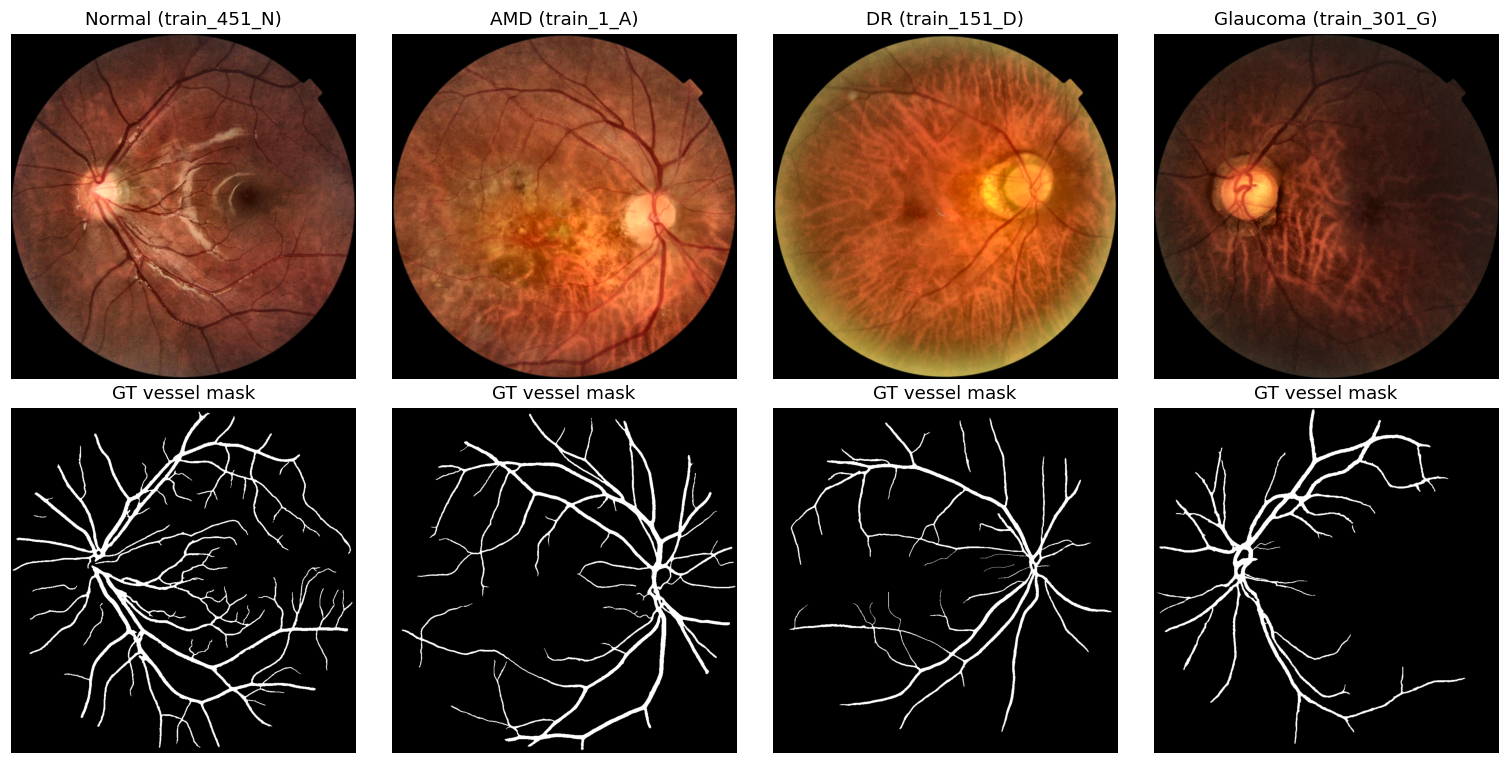

In [5]:
t0 = time.time()
res = Parallel(n_jobs=CFG.N_JOBS)(
    delayed(preprocess)(r['img_path'], r['mask_path']) for r in tqdm(fives.to_dict('records'), desc='FIVES 전처리'))
F_IMG = np.stack([r[0] for r in res])
F_FOV = np.stack([r[1] for r in res])
F_VES = np.stack([r[2] for r in res])
fives = pd.concat([fives, pd.DataFrame([r[3] for r in res])], axis=1)
del res
gc.collect()
print(f'{time.time() - t0:.0f}s | 영상 {F_IMG.shape}, {F_IMG.nbytes / 1e9:.2f} GB')
print('FOV 내 혈관 비율:', round(float(F_VES.sum() / F_FOV.sum()), 4))

# 학습/검증/테스트 인덱스 (공식 test는 그대로, train에서 질환별 층화로 검증셋 분리)
rng = np.random.RandomState(CFG.SEED)
tr_idx, va_idx = [], []
for _, g in fives[fives.split == 'train'].groupby('label'):
    idx = rng.permutation(g.index.values)
    nv = max(1, int(round(len(idx) * CFG.VAL_FRAC)))
    va_idx += idx[:nv].tolist()
    tr_idx += idx[nv:].tolist()
te_idx = fives.index[fives.split == 'test'].tolist()
print(f'train {len(tr_idx)} / val {len(va_idx)} / test {len(te_idx)}')

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for j, lab in enumerate(GROUP_ORDER):
    sel = fives.index[(fives.label == lab) & (fives.split == 'train')]
    if len(sel) == 0:
        axes[0, j].axis('off'); axes[1, j].axis('off')
        continue
    k = sel[0]
    axes[0, j].imshow(F_IMG[k]); axes[0, j].set_title(f'{lab} ({fives.id[k]})')
    axes[1, j].imshow(F_VES[k], cmap='gray'); axes[1, j].set_title('GT vessel mask')
for a in axes.ravel():
    a.axis('off')
plt.tight_layout(); savefig('01_fives_examples'); plt.show()

## 2. U-Net 학습

- **모델:** `segmentation_models_pytorch` U-Net + ResNet34 인코더(ImageNet 사전학습)
- **입력:** FOV 안쪽을 중심으로 뽑은 `CROP`×`CROP` 무작위 패치, 추론은 1024 전체 영상
- **손실:** BCE + Dice + **soft clDice**(Shit et al., CVPR 2021). 가는 혈관이 끊기면 세그먼트가 잘게 쪼개져 굴곡도가 왜곡되므로, 중심선 연결성을 직접 최적화합니다.
- **증강:** 반전·회전·약한 아핀·밝기/대비/감마/색조·블러. 탄성 변형은 혈관 모양을 인위적으로 휘게 만들 수 있어 넣지 않았습니다.

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import albumentations as A
import segmentation_models_pytorch as smp

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP = DEVICE.type == 'cuda'
torch.manual_seed(CFG.SEED)
print('device:', DEVICE, '| GPU 수:', torch.cuda.device_count(),
      '|', torch.cuda.get_device_name(0) if USE_AMP else 'CPU (GPU 가속기를 켜세요)')
assert CFG.IMG_SIZE % 32 == 0 and CFG.CROP % 32 == 0

MEAN = np.array([0.485, 0.456, 0.406], np.float32) * 255
STD = np.array([0.229, 0.224, 0.225], np.float32) * 255


def to_tensor(img):
    x = (img.astype(np.float32) - MEAN) / STD
    return torch.from_numpy(np.ascontiguousarray(x.transpose(2, 0, 1)))


train_aug = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Affine(rotate=(-20, 20), scale=(0.9, 1.1), p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.RandomGamma(gamma_limit=(80, 120), p=0.3),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=15, val_shift_limit=10, p=0.3),
    A.GaussianBlur(blur_limit=(3, 5), p=0.1),
])


class PatchDS(Dataset):
    # FOV 내부를 중심으로 하는 무작위 패치
    def __init__(self, idx, n_samples, crop, aug=None):
        self.idx, self.n, self.crop, self.aug = np.asarray(idx), n_samples, crop, aug

    def __len__(self):
        return self.n

    def __getitem__(self, i):
        k = self.idx[np.random.randint(len(self.idx))]
        img, ves, fov = F_IMG[k], F_VES[k], F_FOV[k]
        S, c = img.shape[0], self.crop
        for _ in range(20):
            cy, cx = np.random.randint(0, S, 2)
            if fov[cy, cx]:
                break
        y0 = int(np.clip(cy - c // 2, 0, S - c))
        x0 = int(np.clip(cx - c // 2, 0, S - c))
        im = img[y0:y0 + c, x0:x0 + c]
        m = ves[y0:y0 + c, x0:x0 + c].astype(np.uint8)
        if self.aug is not None:
            out = self.aug(image=im, mask=m)
            im, m = out['image'], out['mask']
        return to_tensor(im), torch.from_numpy(m[None].astype(np.float32))


def _worker_init(wid):
    np.random.seed((torch.initial_seed() + wid) % 2 ** 32)

device: cuda | GPU 수: 2 | Tesla T4


In [7]:
# ---- 손실 함수: BCE + Dice + soft clDice ----
def soft_erode(x):
    p1 = -F.max_pool2d(-x, (3, 1), 1, (1, 0))
    p2 = -F.max_pool2d(-x, (1, 3), 1, (0, 1))
    return torch.min(p1, p2)


def soft_dilate(x):
    return F.max_pool2d(x, 3, 1, 1)


def soft_skel(x, iters):
    skel = F.relu(x - soft_dilate(soft_erode(x)))
    for _ in range(iters):
        x = soft_erode(x)
        delta = F.relu(x - soft_dilate(soft_erode(x)))
        skel = skel + F.relu(delta - skel * delta)
    return skel


def dice_loss(p, y, eps=1.0):
    num = 2 * (p * y).sum((1, 2, 3)) + eps
    den = p.sum((1, 2, 3)) + y.sum((1, 2, 3)) + eps
    return (1 - num / den).mean()


def cldice_loss(p, y, iters, eps=1.0):
    sp, sy = soft_skel(p, iters), soft_skel(y, iters)
    tprec = ((sp * y).sum((1, 2, 3)) + eps) / (sp.sum((1, 2, 3)) + eps)
    tsens = ((sy * p).sum((1, 2, 3)) + eps) / (sy.sum((1, 2, 3)) + eps)
    return (1 - 2 * tprec * tsens / (tprec + tsens)).mean()


class VesselLoss(nn.Module):
    def forward(self, logits, y):
        logits = logits.float()                  # AMP에서도 손실은 float32로 계산
        p = torch.sigmoid(logits)
        loss = F.binary_cross_entropy_with_logits(logits, y) + dice_loss(p, y)
        if CFG.CLDICE_W > 0:
            loss = loss + CFG.CLDICE_W * cldice_loss(p, y, CFG.SKEL_ITERS)
        return loss


def build_model(weights='default'):
    w = CFG.ENCODER_WEIGHTS if weights == 'default' else weights
    return smp.Unet(encoder_name=CFG.ENCODER, encoder_weights=w, in_channels=3, classes=1)


def unwrap(m):
    return m.module if isinstance(m, nn.DataParallel) else m


@torch.no_grad()
def forward_tta(model, x, tta=True):
    with torch.autocast(device_type=DEVICE.type, enabled=USE_AMP):
        p = torch.sigmoid(model(x).float())
        if tta:
            p = p + torch.sigmoid(model(x.flip(-1)).float()).flip(-1)
            p = p + torch.sigmoid(model(x.flip(-2)).float()).flip(-2)
            p = p / 3
    return p[:, 0].float()


@torch.no_grad()
def predict_probs(model, imgs, tta=True, bs=2):
    model.eval()
    out = []
    for i in range(0, len(imgs), bs):
        x = torch.stack([to_tensor(im) for im in imgs[i:i + bs]]).to(DEVICE)
        out.append(forward_tta(model, x, tta).cpu().numpy().astype(np.float16))
    return np.concatenate(out)


def dice_np(pred, gt, fov):
    p, g = pred[fov], gt[fov]
    return 2 * (p & g).sum() / (p.sum() + g.sum() + 1e-8)

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

ep   1 | loss 1.9160 | val Dice nan | best -1.0000 | 50s
ep   2 | loss 1.2365 | val Dice 0.7370 | best 0.7370 | 53s
ep   3 | loss 0.8621 | val Dice nan | best 0.7370 | 47s
ep   4 | loss 0.5107 | val Dice 0.8804 | best 0.8804 | 52s
ep   5 | loss 0.3641 | val Dice nan | best 0.8804 | 48s
ep   6 | loss 0.3355 | val Dice 0.8884 | best 0.8884 | 52s
ep   7 | loss 0.3120 | val Dice nan | best 0.8884 | 47s
ep   8 | loss 0.2995 | val Dice 0.9054 | best 0.9054 | 52s
ep   9 | loss 0.2835 | val Dice nan | best 0.9054 | 47s
ep  10 | loss 0.2730 | val Dice 0.9073 | best 0.9073 | 52s
ep  11 | loss 0.2726 | val Dice nan | best 0.9073 | 48s
ep  12 | loss 0.2867 | val Dice 0.9101 | best 0.9101 | 53s
ep  13 | loss 0.2686 | val Dice nan | best 0.9101 | 48s
ep  14 | loss 0.2696 | val Dice 0.9096 | best 0.9101 | 52s
ep  15 | loss 0.2707 | val Dice nan | best 0.9101 | 48s
ep  16 | loss 0.2580 | val Dice 0.9177 | best 0.9177 | 52s
ep  17 | loss 0.2543 | val Dice nan | best 0.9177 | 47s
ep  18 | loss 0.2560 | 

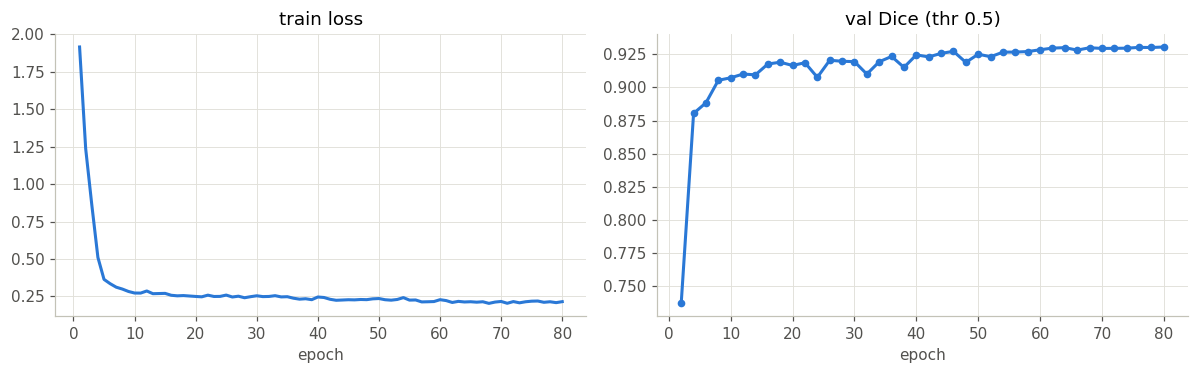

선택된 임계값: 0.6 | val Dice: 0.9335


In [8]:
def train_model():
    model = build_model()
    if torch.cuda.device_count() > 1:
        model = nn.DataParallel(model)
    model.to(DEVICE)
    dl = DataLoader(PatchDS(tr_idx, CFG.SAMPLES_PER_EPOCH, CFG.CROP, train_aug),
                    batch_size=CFG.BATCH, shuffle=False, num_workers=CFG.NUM_WORKERS,
                    pin_memory=USE_AMP, drop_last=True, worker_init_fn=_worker_init,
                    persistent_workers=CFG.NUM_WORKERS > 0)
    opt = torch.optim.AdamW(model.parameters(), lr=CFG.LR, weight_decay=CFG.WD)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=CFG.LR, total_steps=CFG.EPOCHS * len(dl),
                                                pct_start=0.05)
    scaler = torch.amp.GradScaler('cuda', enabled=USE_AMP)
    crit = VesselLoss()
    best, hist = -1.0, []
    for ep in range(1, CFG.EPOCHS + 1):
        model.train()
        t0, tl = time.time(), 0.0
        for x, y in dl:
            x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with torch.autocast(device_type=DEVICE.type, enabled=USE_AMP):
                logits = model(x)
            loss = crit(logits, y)
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()
            sched.step()
            tl += loss.item()
        rec = dict(epoch=ep, train_loss=tl / len(dl))
        if ep % CFG.VAL_EVERY == 0 or ep == CFG.EPOCHS:
            probs = predict_probs(model, F_IMG[va_idx], tta=False)
            rec['val_dice'] = float(np.mean([dice_np(p >= 0.5, F_VES[k], F_FOV[k]) for p, k in zip(probs, va_idx)]))
            if rec['val_dice'] > best:
                best = rec['val_dice']
                torch.save(unwrap(model).state_dict(), CKPT_PATH)
        hist.append(rec)
        print(f"ep {ep:3d} | loss {rec['train_loss']:.4f} | val Dice {rec.get('val_dice', float('nan')):.4f} "
              f"| best {best:.4f} | {time.time() - t0:.0f}s")
    return pd.DataFrame(hist)


if CFG.PRETRAINED_CKPT is not None:
    ckpt = Path(CFG.PRETRAINED_CKPT)
    print('저장된 가중치 사용:', ckpt)
elif CFG.RUN_TRAIN or not CKPT_PATH.exists():
    hist = train_model()
    hist.to_csv(CFG.WORK / 'train_history.csv', index=False)
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
    ax[0].plot(hist.epoch, hist.train_loss, color='#2a78d6', lw=2); ax[0].set_title('train loss'); ax[0].set_xlabel('epoch')
    h = hist.dropna(subset=['val_dice'])
    ax[1].plot(h.epoch, h.val_dice, color='#2a78d6', lw=2, marker='o', ms=4); ax[1].set_title('val Dice (thr 0.5)'); ax[1].set_xlabel('epoch')
    plt.tight_layout(); savefig('02_training'); plt.show()
    ckpt = CKPT_PATH
else:
    ckpt = CKPT_PATH

model = build_model(weights=None)
model.load_state_dict(torch.load(ckpt, map_location='cpu'))
model.to(DEVICE).eval()

# 검증셋에서 Dice(=F1)가 최대가 되는 임계값 선택 (TTA 적용)
va_probs = predict_probs(model, F_IMG[va_idx])
ths = np.round(np.arange(0.30, 0.71, 0.05), 2)
th_scores = [np.mean([dice_np(p >= t, F_VES[k], F_FOV[k]) for p, k in zip(va_probs, va_idx)]) for t in ths]
THR = float(ths[int(np.argmax(th_scores))])
print('선택된 임계값:', THR, '| val Dice:', round(max(th_scores), 4))
del va_probs

## 3. FIVES 테스트셋 분할 평가

FOV 내부 픽셀 기준으로 Dice, Sensitivity, Specificity, AUC를 계산하고, 굴곡도 목적에 맞게 **clDice**(중심선 기준 연결성)와 **연결 요소 수 차이**(β0 오차)도 함께 봅니다. 질환군별로 나눠 보면 병변이 분할 오류를 얼마나 유발하는지 알 수 있습니다.

In [9]:
from sklearn.metrics import roc_auc_score

EIGHT = np.ones((3, 3), bool)


def seg_metrics(prob, gt, fov, thr):
    pred = (prob >= thr) & fov
    p, g = pred[fov], gt[fov]
    tp, fp = (p & g).sum(), (p & ~g).sum()
    fn, tn = (~p & g).sum(), (~p & ~g).sum()
    pr = prob[fov].astype(np.float32)
    sel = np.random.RandomState(0).choice(len(pr), min(len(pr), 200_000), replace=False)
    auc = roc_auc_score(g[sel], pr[sel]) if 0 < g[sel].sum() < len(sel) else np.nan
    sp, sg = skeletonize(pred), skeletonize(gt & fov)
    tprec = (sp & gt).sum() / max(sp.sum(), 1)
    tsens = (sg & pred).sum() / max(sg.sum(), 1)
    return dict(dice=2 * tp / (2 * tp + fp + fn + 1e-8), sens=tp / (tp + fn + 1e-8), spec=tn / (tn + fp + 1e-8),
                acc=(tp + tn) / (tp + tn + fp + fn), auc=auc,
                cldice=2 * tprec * tsens / (tprec + tsens + 1e-8),
                betti0_err=abs(ndi.label(pred, EIGHT)[1] - ndi.label(gt & fov, EIGHT)[1]))


te_probs = predict_probs(model, F_IMG[te_idx])
TE_PRED = np.stack([(p >= THR) & F_FOV[k] for p, k in zip(te_probs, te_idx)])
rows = Parallel(n_jobs=CFG.N_JOBS)(delayed(seg_metrics)(p, F_VES[k], F_FOV[k], THR) for p, k in zip(te_probs, te_idx))
seg_eval = pd.concat([fives.loc[te_idx, ['id', 'label']].reset_index(drop=True), pd.DataFrame(rows)], axis=1)
seg_eval.to_csv(CFG.WORK / 'fives_test_segmentation_metrics.csv', index=False)

SEG_COLS = ['dice', 'cldice', 'sens', 'spec', 'auc', 'betti0_err']
summary = seg_eval.groupby('label')[SEG_COLS].mean().reindex([g for g in GROUP_ORDER if g in seg_eval.label.unique()])
summary.loc['전체'] = seg_eval[SEG_COLS].mean()
display(summary.round(4))
groups = [g.dice.values for _, g in seg_eval.groupby('label')]
if len(groups) > 1:
    H, p = stats.kruskal(*groups)
    print(f'질환군 간 Dice 차이 Kruskal-Wallis: H={H:.2f}, p={p:.3g}')

,dice,cldice,sens,spec,auc,betti0_err
label,,,,,,
Normal,0.9178,0.9315,0.8977,0.9930,0.9950,29.940
AMD,0.9332,0.9360,0.9251,0.9938,0.9955,16.360
DR,0.9109,0.9220,0.8911,0.9943,0.9949,15.960
Glaucoma,0.8656,0.8759,0.8486,0.9946,0.9895,13.200
전체,0.9069,0.9164,0.8906,0.9939,0.9937,18.865


질환군 간 Dice 차이 Kruskal-Wallis: H=17.48, p=0.000564


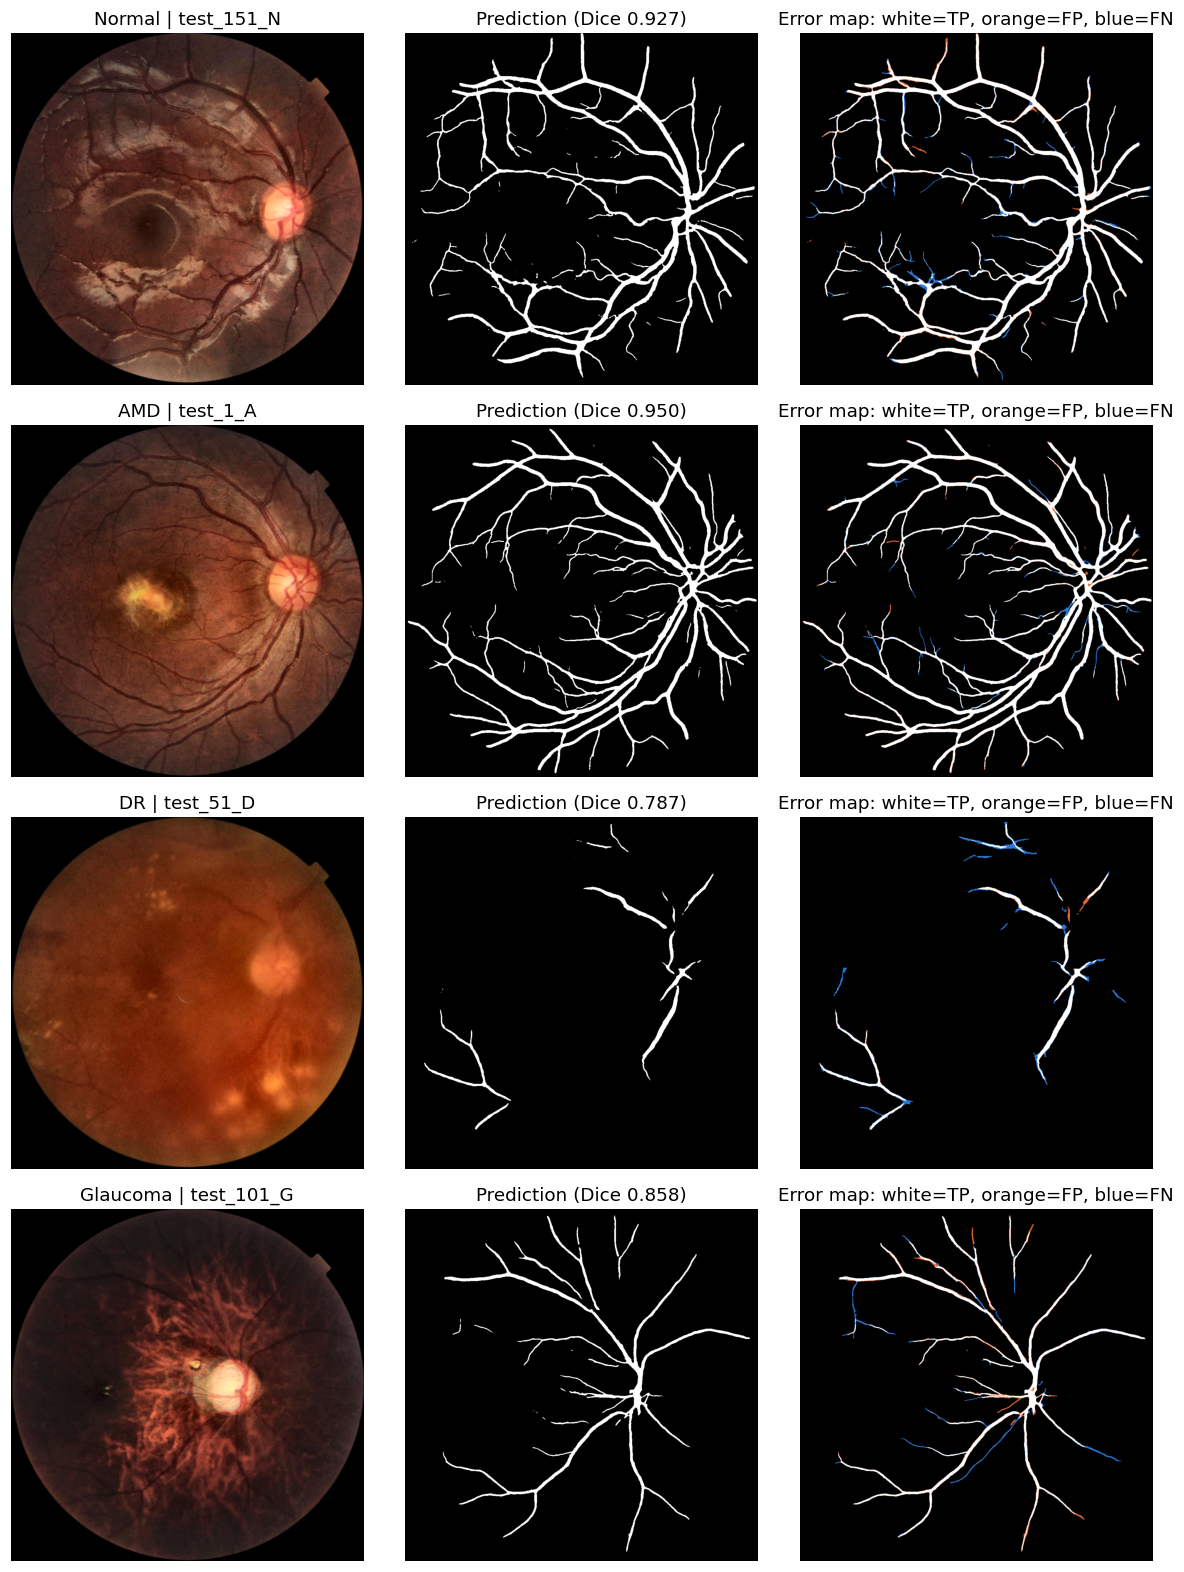

In [10]:
# 질환군별 예시: 흰색=정답과 일치, 주황=과분할(FP), 파랑=누락(FN)
fig, axes = plt.subplots(len(GROUP_ORDER), 3, figsize=(11, 3.6 * len(GROUP_ORDER)))
for i, lab in enumerate(GROUP_ORDER):
    pos = [j for j, k in enumerate(te_idx) if fives.label[k] == lab]
    if not pos:
        for a in axes[i]: a.axis('off')
        continue
    j = pos[0]; k = te_idx[j]
    gt, pr = F_VES[k], TE_PRED[j]
    err = np.zeros(gt.shape + (3,), np.uint8)
    err[gt & pr] = (255, 255, 255)
    err[~gt & pr] = (235, 104, 52)
    err[gt & ~pr] = (42, 120, 214)
    axes[i, 0].imshow(F_IMG[k]); axes[i, 0].set_title(f'{lab} | {fives.id[k]}')
    axes[i, 1].imshow(pr, cmap='gray'); axes[i, 1].set_title(f"Prediction (Dice {seg_eval.dice[j]:.3f})")
    axes[i, 2].imshow(err); axes[i, 2].set_title('Error map: white=TP, orange=FP, blue=FN')
for a in axes.ravel():
    a.axis('off')
plt.tight_layout(); savefig('03_fives_test_examples'); plt.show()

## 4. 스켈레톤 → 혈관 세그먼트 → 굴곡도

1. **정리:** FOV 가장자리 제외, 작은 연결 요소 제거, 작은 구멍 채움
2. **스켈레톤화** 후 **분기점**(주변 8픽셀을 한 바퀴 돌 때 0→1 전이가 3회 이상) 검출
3. 분기점과 그 주변 1픽셀을 제거해 스켈레톤을 **세그먼트**로 나누고, 분기점에 붙은 짧은 **잔가지(spur)** 는 2회 반복 제거
4. 각 세그먼트의 픽셀을 순서대로 정렬(그래프 최장 경로) → **B-spline 평활** → 2px 간격 재샘플. 곡률 기반 지표는 스플라인 경계 효과를 피하려고 양 끝 10px을 빼고 계산
5. 세그먼트별 지표 계산 → 영상 단위 **길이 가중 평균 / 중앙값 / 상위 10%** 로 집계

| 지표 | 정의 | 단위 |
|---|---|---|
| DM | 호 길이 / 현 길이 | 무차원 (1 = 직선) |
| ICM | DM × (변곡점 수 + 1) | 무차원 |
| SOAM | Σ\|방향각 변화\| / 길이 | rad/px |
| CE | ∫κ² ds / 길이 (곡률 에너지) | 1/px² |
| TD | (n−1)/n · (1/L) · Σ(하위 호/현 − 1), n = 변곡점으로 나눈 구간 수 (Grisan 2008) | 1/px |

TD는 정의상 변곡점이 없는 C자형 세그먼트에서 0입니다. 세그먼트 폭(거리 변환 기반)도 저장해 두었다가 민감도 분석에 씁니다.

In [11]:
_OFFS = [(-1, 0), (-1, 1), (0, 1), (1, 1), (1, 0), (1, -1), (0, -1), (-1, -1)]   # N부터 시계 방향
_NB8 = [(dy, dx) for dy in (-1, 0, 1) for dx in (-1, 0, 1) if (dy, dx) != (0, 0)]


def remove_small(mask, min_size):
    lab, n = ndi.label(mask, structure=EIGHT)
    if n == 0:
        return mask
    keep = np.bincount(lab.ravel()) >= min_size
    keep[0] = False
    return keep[lab]


def fill_small_holes(mask, max_size):
    lab, n = ndi.label(~mask)
    if n == 0:
        return mask
    fill = np.bincount(lab.ravel()) < max_size
    fill[0] = False
    return mask | fill[lab]


def clean_vessel_mask(ves, fov, cfg=CFG):
    fov_e = ndi.binary_erosion(fov, iterations=cfg.FOV_ERODE) if cfg.FOV_ERODE else fov
    m = ves & fov_e
    m = remove_small(m, cfg.MIN_OBJ)
    return fill_small_holes(m, cfg.MIN_HOLE)


def neighbor_stack(skel):
    p = np.pad(skel, 1)
    H, W = skel.shape
    return np.stack([p[1 + dy:1 + dy + H, 1 + dx:1 + dx + W] for dy, dx in _OFFS])


def skeleton_nodes(skel):
    nb = neighbor_stack(skel)
    n = nb.sum(0)
    cn = (~nb & np.roll(nb, -1, axis=0)).sum(0)          # 0→1 전이 수 (crossing number)
    junction = skel & ((cn >= 3) | (n >= 4))
    endpoint = skel & (n == 1)
    return junction, endpoint


def _bfs(nbrs, src):
    dist = np.full(len(nbrs), -1)
    prev = np.full(len(nbrs), -1)
    dist[src] = 0
    q = deque([src])
    while q:
        u = q.popleft()
        for v in nbrs[u]:
            if dist[v] < 0:
                dist[v] = dist[u] + 1
                prev[v] = u
                q.append(v)
    return dist, prev


def order_component(pix):
    # 픽셀 집합에서 가장 긴 경로(그래프 지름)를 순서대로 반환
    index = {(y, x): i for i, (y, x) in enumerate(pix.tolist())}
    nbrs = [[index[(y + dy, x + dx)] for dy, dx in _NB8 if (y + dy, x + dx) in index] for y, x in pix.tolist()]
    ends = [i for i, nb in enumerate(nbrs) if len(nb) == 1]
    d, _ = _bfs(nbrs, ends[0] if ends else 0)
    a = int(d.argmax())
    d, prev = _bfs(nbrs, a)
    b = int(d.argmax())
    path = [b]
    while path[-1] != a:
        path.append(int(prev[path[-1]]))
    return pix[path[::-1]]


def extract_segments(skel, cfg=CFG, min_pix=None):
    skel = skel.copy()
    for _ in range(2):                                     # 잔가지 제거 2회
        junc, endp = skeleton_nodes(skel)
        if not junc.any():
            break
        zone = ndi.binary_dilation(junc, structure=EIGHT)      # 분기점 + 주변 8픽셀
        branches = skel & ~zone                                  # (분기점만 빼면 가지끼리 대각선으로 붙을 수 있음)
        lab, n = ndi.label(branches, structure=EIGHT)
        if n == 0:
            break
        near_j = ndi.binary_dilation(zone, structure=EIGHT) & branches
        size = np.bincount(lab.ravel(), minlength=n + 1)
        touches = np.bincount(lab[near_j], minlength=n + 1) > 0
        has_end = np.bincount(lab[endp & branches], minlength=n + 1) > 0
        spur = touches & has_end & (size < cfg.SPUR_LEN)
        spur[0] = False
        if not spur.any():
            break
        skel &= ~spur[lab]
    junc, _ = skeleton_nodes(skel)
    zone = ndi.binary_dilation(junc, structure=EIGHT)
    branches = skel & ~zone
    near_j = ndi.binary_dilation(zone, structure=EIGHT)
    lab, n = ndi.label(branches, structure=EIGHT)
    min_pix = min_pix if min_pix is not None else int(cfg.MIN_SEG_LEN * 0.6)
    segs = []
    for l, sl in enumerate(ndi.find_objects(lab), start=1):
        if sl is None:
            continue
        ys, xs = np.nonzero(lab[sl] == l)
        if len(ys) < min_pix:
            continue
        pix = np.c_[ys + sl[0].start, xs + sl[1].start]
        path = order_component(pix)
        n_junc_ends = int(near_j[tuple(path[0])]) + int(near_j[tuple(path[-1])])
        segs.append(dict(coords=path, n_junction_ends=n_junc_ends))
    return segs

In [12]:
METRICS = ['DM', 'ICM', 'SOAM', 'CE', 'TD']


def _spline(coords, cfg=CFG):
    pts = coords[:, ::-1].astype(np.float64)                     # (x, y)
    keep = np.r_[True, np.any(np.diff(pts, axis=0) != 0, axis=1)]
    pts = pts[keep]
    if len(pts) < 6:
        return None
    u = np.r_[0, np.cumsum(np.hypot(*np.diff(pts, axis=0).T))]
    u /= u[-1]
    try:
        tck, _ = splprep(pts.T, u=u, s=cfg.SPLINE_S * len(pts), k=3)
    except Exception:
        return None
    dense = np.linspace(0, 1, max(400, 4 * len(pts)))
    x, y = splev(dense, tck)
    arc = np.r_[0, np.cumsum(np.hypot(np.diff(x), np.diff(y)))]
    L = arc[-1]
    n = max(int(L / cfg.STEP), 8)
    return tck, np.interp(np.linspace(0, L, n + 1), arc, dense), L


def segment_tortuosity(coords, cfg=CFG):
    r = _spline(coords, cfg)
    if r is None:
        return None
    tck, u, L = r
    x, y = splev(u, tck)
    dx, dy = splev(u, tck, der=1)
    ddx, ddy = splev(u, tck, der=2)
    kappa = (dx * ddy - dy * ddx) / (np.hypot(dx, dy) ** 3 + 1e-12)
    ds = L / (len(u) - 1)
    chord = float(np.hypot(x[-1] - x[0], y[-1] - y[0]))
    DM = L / max(chord, 1e-6)

    # 곡률 기반 지표는 양 끝(스플라인 경계 효과)을 제외한 내부 구간에서 계산
    e = min(cfg.END_TRIM, (len(u) - 1) // 4)
    inner = slice(e, len(u) - e)
    k_in = kappa[inner]
    L_in = ds * (len(k_in) - 1)

    # 변곡점: |κ| > KAPPA_MIN 인 같은 부호 구간이 MIN_RUN 이상 이어진 것들 사이의 부호 변화
    sgn = np.where(np.abs(k_in) > cfg.KAPPA_MIN, np.sign(k_in), 0)
    runs, i = [], 0
    while i < len(sgn):
        if sgn[i] == 0:
            i += 1
            continue
        j = i
        while j + 1 < len(sgn) and sgn[j + 1] == sgn[i]:
            j += 1
        if j - i + 1 >= cfg.MIN_RUN:
            if runs and runs[-1][0] == sgn[i]:
                runs[-1] = (sgn[i], runs[-1][1], j)
            else:
                runs.append((sgn[i], i, j))
        i = j + 1
    infl = [e + (runs[k][2] + runs[k + 1][1]) // 2 for k in range(len(runs) - 1)]

    theta = np.unwrap(np.arctan2(dy[inner], dx[inner]))
    SOAM = float(np.abs(np.diff(theta)).sum() / L_in)
    CE = float(np.sum(k_in ** 2) * ds / L_in)

    xy = np.c_[x, y]
    bounds = [0] + infl + [len(u) - 1]
    n_sub = len(bounds) - 1
    acc = 0.0
    for a, b in zip(bounds[:-1], bounds[1:]):
        if b - a < 1:
            continue
        la = np.hypot(*np.diff(xy[a:b + 1], axis=0).T).sum()
        acc += la / max(np.hypot(*(xy[b] - xy[a])), 1e-6) - 1
    TD = (n_sub - 1) / n_sub * acc / L if n_sub > 1 else 0.0
    return dict(length=float(L), chord=chord, DM=float(DM), n_infl=len(infl),
                ICM=float(DM * (len(infl) + 1)), SOAM=SOAM, CE=CE, TD=float(TD),
                cx=float(x.mean()), cy=float(y.mean()))


def image_tortuosity(ves_bin, fov, cfg=CFG, return_lines=False):
    m = clean_vessel_mask(ves_bin, fov, cfg)
    skel = skeletonize(m)
    segs = extract_segments(skel, cfg)
    dt = ndi.distance_transform_edt(m)
    rows, lines = [], []
    for s in segs:
        c = s['coords']
        t = segment_tortuosity(c, cfg)
        if t is None or t['length'] < cfg.MIN_SEG_LEN:
            continue
        t['width'] = float(2 * dt[c[:, 0], c[:, 1]].mean() - 1)       # 중심선 거리변환 기반 폭
        t['n_junction_ends'] = s['n_junction_ends']
        rows.append(t)
        lines.append(c)
    seg = pd.DataFrame(rows, columns=['length', 'chord', 'DM', 'n_infl', 'ICM', 'SOAM', 'CE', 'TD',
                                      'cx', 'cy', 'width', 'n_junction_ends'])
    info = dict(vessel_density=float(m.sum() / max(fov.sum(), 1)), skel_len_px=int(skel.sum()))
    return (seg, info, lines) if return_lines else (seg, info)


def aggregate_segments(seg, min_len=None, min_width=None):
    s = seg
    if min_len is not None:
        s = s[s['length'] >= min_len]
    if min_width is not None:
        s = s[s['width'] >= min_width]
    out = {'n_seg': len(s), 'total_len': float(s['length'].sum()) if len(s) else 0.0}
    for m in METRICS:
        if len(s) == 0:
            out[f'{m}_lw'] = out[f'{m}_med'] = out[f'{m}_p90'] = np.nan
            continue
        v, w = s[m].values, s['length'].values
        out[f'{m}_lw'] = float(np.average(v, weights=w))
        out[f'{m}_med'] = float(np.median(v))
        out[f'{m}_p90'] = float(np.percentile(v, 90))
    return out


def run_tortuosity(masks, fovs, ids, n_jobs=None):
    res = Parallel(n_jobs=n_jobs or CFG.N_JOBS)(
        delayed(image_tortuosity)(m, f) for m, f in tqdm(zip(masks, fovs), total=len(ids), desc='굴곡도'))
    segs, rows = [], []
    for i, (seg, info) in zip(ids, res):
        if len(seg):
            segs.append(seg.assign(image_id=i))
        rows.append({'image_id': i, **info, **aggregate_segments(seg)})
    return (pd.concat(segs, ignore_index=True) if segs else pd.DataFrame()), pd.DataFrame(rows)

### 굴곡도 계산 검증 (합성 곡선)

실제 데이터에 쓰기 전에 모양을 아는 곡선으로 확인합니다. 직선은 DM≈1·변곡점 0, 원호는 곡률 ≈ 1/반지름, 사인파는 진폭이 커질수록 모든 지표가 증가하고 변곡점 수가 반주기 수와 맞아야 합니다. 마지막 표는 굵은 혈관 모양을 그린 마스크에 전체 파이프라인(스켈레톤 → 세그먼트 → 지표)을 적용한 결과입니다.

In [13]:
def _curve_pixels(x, y):
    # 연속 곡선 → 끊김 없는 8-연결 픽셀 좌표 (row, col)
    xs = np.interp(np.linspace(0, len(x) - 1, len(x) * 4), np.arange(len(x)), x)
    ys = np.interp(np.linspace(0, len(y) - 1, len(y) * 4), np.arange(len(y)), y)
    pix = np.c_[np.round(ys), np.round(xs)].astype(int)
    keep = np.r_[True, np.any(np.diff(pix, axis=0) != 0, axis=1)]
    return pix[keep]


t = np.linspace(0, 1, 400)
tests = {
    '직선 0°': (t * 300, t * 0 + 50),
    '직선 30°': (t * 300 * np.cos(0.52), t * 300 * np.sin(0.52)),
    '원호 R=100 (κ=0.01)': (100 * np.cos(t * 2.5), 100 * np.sin(t * 2.5)),
}
for amp in (3, 8, 15, 25):
    tests[f'사인 진폭 {amp}px, 3주기'] = (t * 300, 50 + amp * np.sin(2 * np.pi * 3 * t))

rows = []
for name, (x, y) in tests.items():
    pix = _curve_pixels(x + 150, y + 150)
    r = segment_tortuosity(pix)
    kap = r['CE'] ** 0.5
    rows.append({'곡선': name, **{k: r[k] for k in ['length', 'DM', 'n_infl', 'ICM', 'SOAM', 'CE', 'TD']},
                 'RMS 곡률': kap})
display(pd.DataFrame(rows).set_index('곡선').round(4))

# 굵은 혈관 모양 마스크에 전체 파이프라인 적용
S = 512
canvas = np.zeros((S, S), np.uint8)
yy, xx = np.mgrid[:S, :S]
fov_syn = (yy - S / 2) ** 2 + (xx - S / 2) ** 2 < (S / 2 - 5) ** 2
for k, amp in enumerate([0, 6, 14, 24]):
    xs = np.linspace(60, 450, 300)
    ys = 90 + k * 110 + amp * np.sin(2 * np.pi * 3 * (xs - 60) / 390)
    pts = np.c_[xs, ys].round().astype(np.int32)
    cv2.polylines(canvas, [pts], False, 255, thickness=5)
cv2.line(canvas, (256, 90), (256, 420), 255, 3)          # 분기점을 만드는 수직 혈관
seg_syn, info_syn = image_tortuosity(canvas > 0, fov_syn, cfg=type('C', (CFG,), {'FOV_ERODE': 0}))
display(seg_syn.sort_values('cy')[['cy', 'length', 'DM', 'n_infl', 'SOAM', 'TD', 'width', 'n_junction_ends']].round(3))

,length,DM,n_infl,ICM,SOAM,CE,TD,RMS 곡률
곡선,,,,,,,,
직선 0°,300.0000,1.0000,0,1.0000,0.0000,0.0000,0.0000,0.0000
직선 30°,301.5224,1.0000,0,1.0000,0.0000,0.0000,0.0000,0.0000
원호 R=100 (κ=0.01),248.0352,1.3098,0,1.3098,0.0099,0.0001,0.0000,0.0101
"사인 진폭 3px, 3주기",302.9893,1.0070,1,2.0140,0.0063,0.0001,0.0000,0.0074
"사인 진폭 8px, 3주기",319.2138,1.0614,5,6.3685,0.0188,0.0004,0.0010,0.0206
"사인 진폭 15px, 3주기",355.4800,1.1920,5,7.1519,0.0281,0.0010,0.0027,0.0317
"사인 진폭 25px, 3주기",434.8232,1.4492,5,8.6949,0.0303,0.0015,0.0051,0.0391


,cy,length,DM,n_infl,SOAM,TD,width,n_junction_ends
0,90.051,187.480,1.000,0,0.000,0.000,6.896,1
1,90.051,187.480,1.000,0,0.000,0.000,6.896,1
2,145.000,104.000,1.000,0,0.000,0.000,5.003,2
4,198.472,197.967,1.020,2,0.008,0.000,5.957,1
3,201.012,197.035,1.020,2,0.008,0.000,5.969,1
5,254.000,102.000,1.000,0,0.000,0.000,5.000,2
7,306.915,210.577,1.103,2,0.018,0.001,5.865,1
6,312.679,214.575,1.108,2,0.018,0.001,5.849,1
8,363.000,98.000,1.000,0,0.000,0.000,5.000,2
10,415.031,239.400,1.276,2,0.024,0.002,5.943,1


## 5. FIVES: 편향 점검과 질환군 비교

**5-1. 정답 vs 예측 굴곡도 (테스트 200장).** 같은 영상에서 정답 마스크와 예측 마스크로 각각 굴곡도를 계산해 ICC(2,1, 절대 일치), Spearman 상관, Bland-Altman으로 비교합니다. 이어서 **(예측 − 정답) 차이가 질환군마다 다른지** 검정합니다. DR군에서만 차이가 크게 나오면, 외부 데이터에서 보이는 DR 등급–굴곡도 관계의 일부가 분할 오류에서 왔을 수 있다는 뜻입니다.

**5-2. 정답 기준 질환군 비교 (800장 전체).** 정답 마스크만 쓰므로 분할 오류가 섞이지 않은 기준선입니다.

굴곡도:   0%|          | 0/800 [00:00<?, ?it/s]

굴곡도:   0%|          | 0/200 [00:00<?, ?it/s]

GT 영상당 세그먼트 수 중앙값: 97.0 | 예측: 84.5


,"ICC(2,1)",Spearman ρ,평균 차이(예측−정답),차이[Normal],차이[AMD],차이[DR],차이[Glaucoma],군간 차이 p (KW),군간 차이 p (Holm)
지표,,,,,,,,,
DM_lw,0.4343,0.6924,-0.0009,-0.0024,0.0002,0.0013,-0.0028,0.0262,0.0785
ICM_lw,0.4043,0.6516,-0.0126,-0.0434,0.0465,0.0445,-0.0980,0.1193,0.1670
SOAM_lw,0.7941,0.8881,-0.0006,-0.0008,-0.0004,-0.0004,-0.0009,0.0030,0.0148
CE_lw,0.6303,0.8169,-0.0000,-0.0001,-0.0000,-0.0000,-0.0000,0.0049,0.0194
TD_lw,0.6622,0.7880,-0.0000,-0.0000,-0.0000,-0.0000,-0.0000,0.0835,0.1670


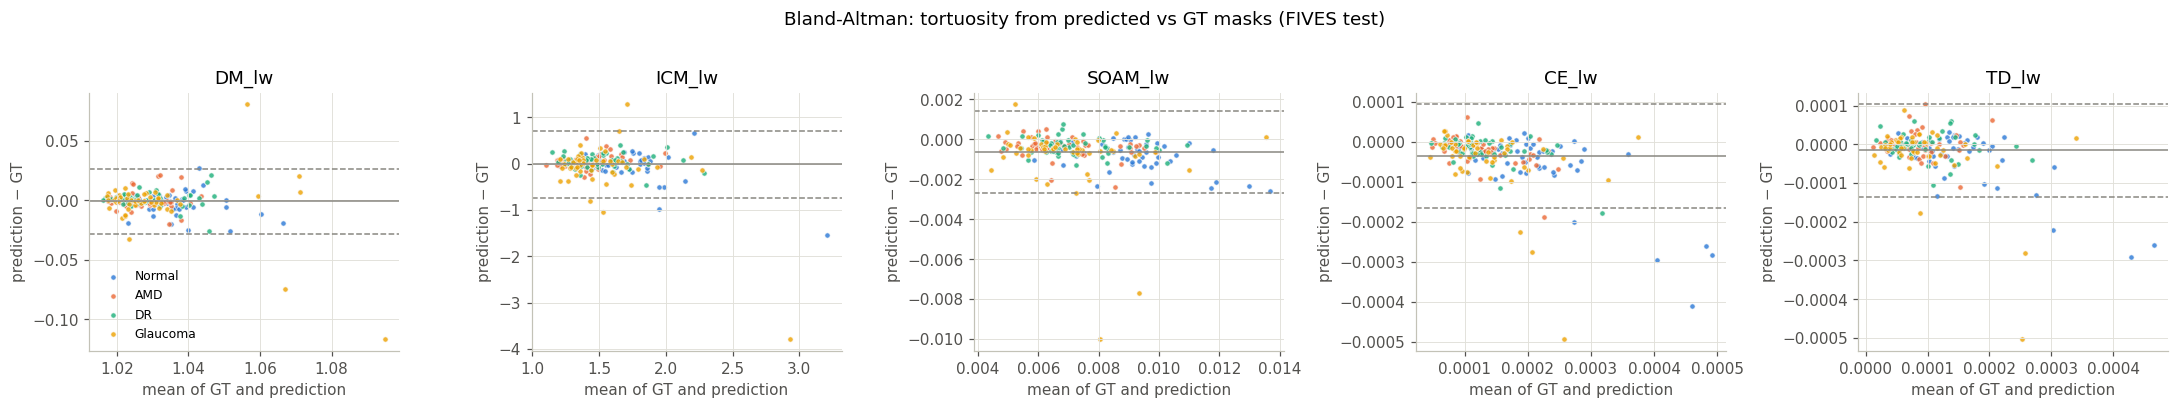

In [14]:
gt_seg, gt_img = run_tortuosity(F_VES, F_FOV, fives.id.tolist())
gt_img = gt_img.merge(fives[['id', 'label', 'split', 'blur', 'bright']], left_on='image_id', right_on='id').drop(columns='id')
pr_seg, pr_img = run_tortuosity(TE_PRED, F_FOV[te_idx], fives.id[te_idx].tolist())
gt_seg.to_csv(CFG.WORK / 'fives_gt_segments.csv.gz', index=False)
gt_img.to_csv(CFG.WORK / 'fives_gt_image_tortuosity.csv', index=False)
pr_img.to_csv(CFG.WORK / 'fives_test_pred_image_tortuosity.csv', index=False)
print('GT 영상당 세그먼트 수 중앙값:', gt_img.n_seg.median(), '| 예측:', pr_img.n_seg.median())


def icc_2_1(a, b):
    X = np.c_[a, b]
    X = X[~np.isnan(X).any(1)]
    n, k = X.shape
    gm = X.mean()
    msr = k * ((X.mean(1) - gm) ** 2).sum() / (n - 1)
    msc = n * ((X.mean(0) - gm) ** 2).sum() / (k - 1)
    sse = ((X - X.mean(1, keepdims=True) - X.mean(0, keepdims=True) + gm) ** 2).sum()
    mse = sse / ((n - 1) * (k - 1))
    return (msr - mse) / (msr + (k - 1) * mse + k * (msc - mse) / n)


def holm(p):
    p = np.asarray(p, float)
    out = np.full(len(p), np.nan)
    ok = ~np.isnan(p)
    idx = np.where(ok)[0][np.argsort(p[ok])]
    m, run = len(idx), 0.0
    for r, i in enumerate(idx):
        run = max(run, (m - r) * p[i])
        out[i] = min(run, 1.0)
    return out


LW = [f'{m}_lw' for m in METRICS]
cmp = gt_img[gt_img.split == 'test'][['image_id', 'label'] + LW].merge(
    pr_img[['image_id'] + LW], on='image_id', suffixes=('_gt', '_pred'))
rows = []
for m in LW:
    a, b = cmp[f'{m}_gt'].values, cmp[f'{m}_pred'].values
    d = b - a
    by = cmp.assign(d=d).groupby('label').d
    kw = stats.kruskal(*[g.dropna().values for _, g in by]) if cmp.label.nunique() > 1 else (np.nan, np.nan)
    rows.append({'지표': m, 'ICC(2,1)': icc_2_1(a, b), 'Spearman ρ': stats.spearmanr(a, b, nan_policy='omit')[0],
                 '평균 차이(예측−정답)': np.nanmean(d),
                 **{f'차이[{g}]': by.mean().get(g, np.nan) for g in GROUP_ORDER},
                 '군간 차이 p (KW)': kw[1]})
agree = pd.DataFrame(rows).set_index('지표')
agree['군간 차이 p (Holm)'] = holm(agree['군간 차이 p (KW)'])
agree.to_csv(CFG.WORK / 'fives_gt_vs_pred_agreement.csv')
display(agree.round(4))

fig, axes = plt.subplots(1, len(LW), figsize=(4 * len(LW), 3.6))
for ax, m in zip(axes, LW):
    a, b = cmp[f'{m}_gt'], cmp[f'{m}_pred']
    mean, diff = (a + b) / 2, b - a
    for g in GROUP_ORDER:
        s = cmp.label == g
        ax.scatter(mean[s], diff[s], s=12, color=GROUP_COLORS[g], label=g, alpha=0.8,
                   edgecolor='#fcfcfb', linewidth=0.5)
    md_, sd = np.nanmean(diff), np.nanstd(diff)
    for v, ls in [(md_, '-'), (md_ + 1.96 * sd, '--'), (md_ - 1.96 * sd, '--')]:
        ax.axhline(v, color='#898781', ls=ls, lw=1)
    ax.set_title(m); ax.set_xlabel('mean of GT and prediction'); ax.set_ylabel('prediction − GT')
axes[0].legend(fontsize=8, frameon=False)
plt.suptitle('Bland-Altman: tortuosity from predicted vs GT masks (FIVES test)', y=1.02)
plt.tight_layout(); savefig('05_bland_altman'); plt.show()

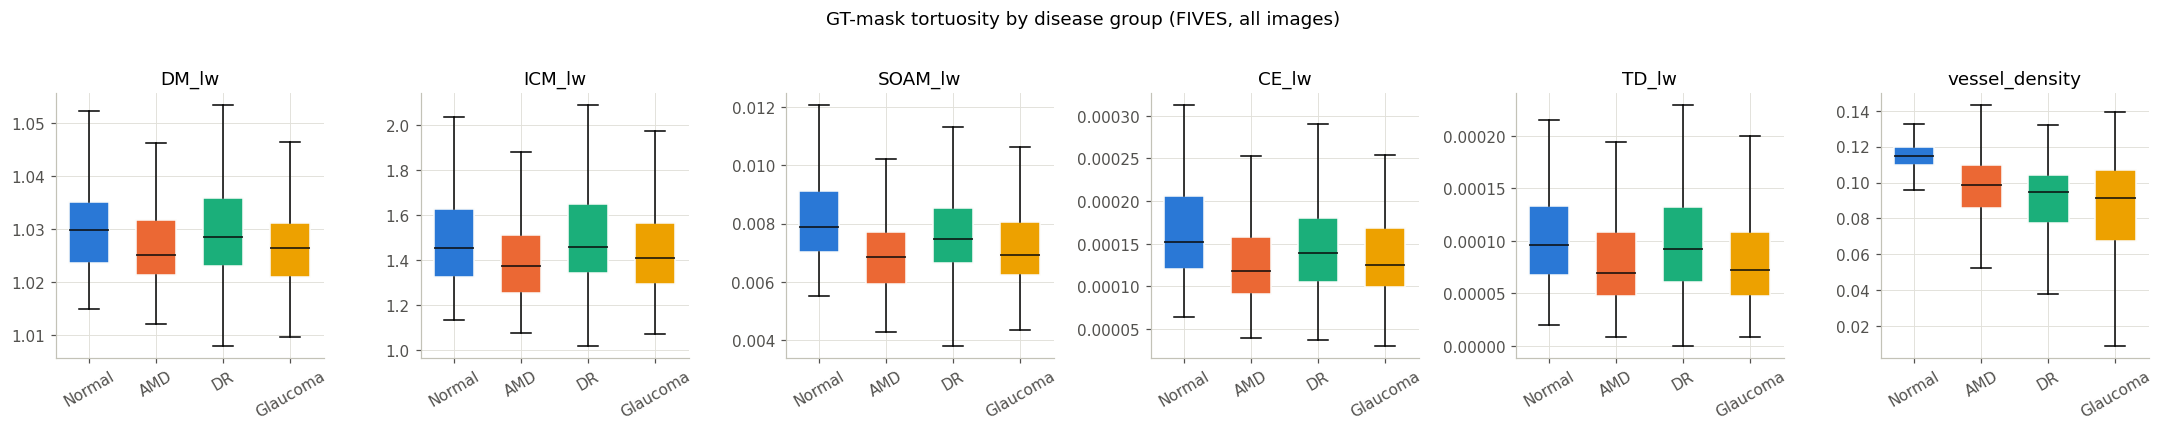

,KW H,KW p,AMD vs Normal p,DR vs Normal p,Glaucoma vs Normal p,AMD vs Normal p(Holm),DR vs Normal p(Holm),Glaucoma vs Normal p(Holm)
지표,,,,,,,,
DM_lw,22.9951,0.0,0.0001,0.4646,0.0003,0.0006,1.0000,0.0020
ICM_lw,26.0071,0.0,0.0001,0.3930,0.0949,0.0006,1.0000,0.3795
SOAM_lw,72.1910,0.0,0.0000,0.0042,0.0000,0.0000,0.0211,0.0000
CE_lw,45.9276,0.0,0.0000,0.0020,0.0000,0.0000,0.0123,0.0000
TD_lw,37.6310,0.0,0.0000,0.3420,0.0000,0.0000,1.0000,0.0001
vessel_density,230.6071,0.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


,DM_lw,ICM_lw,SOAM_lw,CE_lw,TD_lw,vessel_density,n_seg
label,,,,,,,
Normal,1.0297,1.4528,0.0079,0.0002,0.0001,0.1147,113.0
AMD,1.0251,1.3750,0.0069,0.0001,0.0001,0.0984,97.0
DR,1.0285,1.4571,0.0075,0.0001,0.0001,0.0946,80.0
Glaucoma,1.0264,1.4106,0.0069,0.0001,0.0001,0.0915,86.0


In [15]:
# 5-2. 정답 마스크 기준 질환군 비교 (800장)
labs = [g for g in GROUP_ORDER if g in gt_img.label.unique()]
fig, axes = plt.subplots(1, len(LW) + 1, figsize=(3.3 * (len(LW) + 1), 3.8))
rows = []
for ax, m in zip(axes, LW + ['vessel_density']):
    data = [gt_img.loc[gt_img.label == g, m].dropna().values for g in labs]
    bp = ax.boxplot(data, patch_artist=True, showfliers=False, widths=0.6, medianprops=dict(color='#0b0b0b'))
    for patch, g in zip(bp['boxes'], labs):
        patch.set_facecolor(GROUP_COLORS[g]); patch.set_edgecolor('#fcfcfb')
    ax.set_xticks(range(1, len(labs) + 1)); ax.set_xticklabels(labs, rotation=30)
    ax.set_title(m)
    H, p = stats.kruskal(*data)
    row = {'지표': m, 'KW H': H, 'KW p': p}
    if 'Normal' in labs:
        for g in labs:
            if g != 'Normal':
                row[f'{g} vs Normal p'] = stats.mannwhitneyu(data[labs.index(g)], data[labs.index('Normal')]).pvalue
    rows.append(row)
plt.suptitle('GT-mask tortuosity by disease group (FIVES, all images)', y=1.02)
plt.tight_layout(); savefig('05_fives_group_comparison'); plt.show()

grp = pd.DataFrame(rows).set_index('지표')
pcols = [c for c in grp.columns if c.endswith('vs Normal p')]
if pcols:                                                   # 지표×비교 전체에 Holm 보정
    flat = holm(grp[pcols].values.ravel())
    grp[[c.replace(' p', ' p(Holm)') for c in pcols]] = flat.reshape(grp[pcols].shape)
display(grp.round(4))
display(gt_img.groupby('label')[LW + ['vessel_density', 'n_seg']].median().reindex(labs).round(4))